In [3]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


"""
Example to show linear regression using scikit. We first show a scatterplot 
and then fit a line through the data. 
FAO Lake kadim fishinng dataset is taken from https://www.fao.org/4/y4816e/y4816e0i.htm
We plot number of fishers vs. catch. This fit will help authorities issue the license 


"""

panda_df = pd.read_csv('/Users/rjha/code/github/ai-training/data/kadim/fish.csv')

# define columns and labels 
x_column = 'Fishers' 
y_column = 'CPUE' 
x_column_label = 'Number of fishers' 
y_column_label = 'Carp catch'
plot_title = 'fishers vs catch data' 
# see samples
print(panda_df.head())



   Fishers  CPUE
0       12  1400
1       33   900
2      140   250
3      160   110
4       45  1400


In [12]:
# check the Jupyter kernel virtual environment
print(sys.executable)




/Users/rjha/sw/pyvm/ai-training/bin/python3.13


Fishers    int64
CPUE       int64
dtype: object


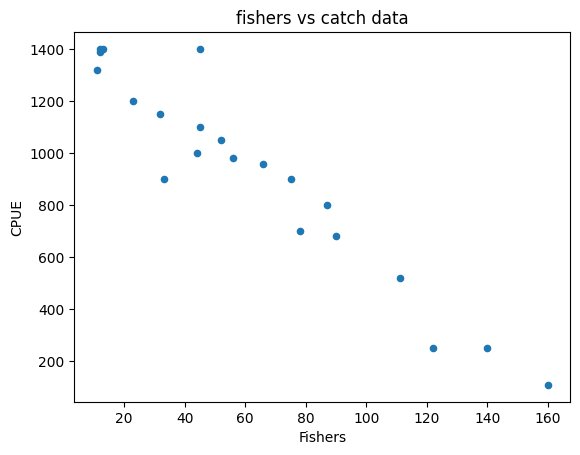

In [2]:
print(panda_df.dtypes)

# plot the data points for visual inspection 
panda_df.plot.scatter(x=x_column, y=y_column, title=plot_title)
plt.show()

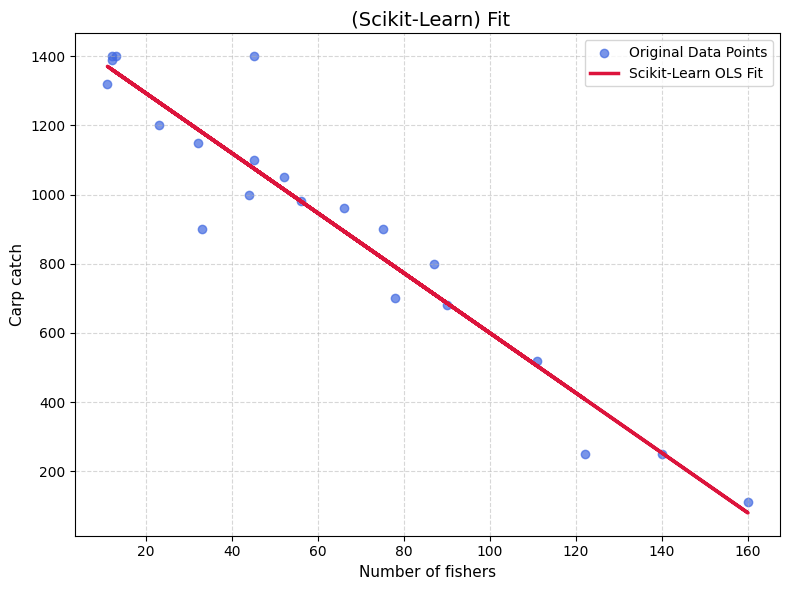

Intercept (Beta 0): 1465.8140
Slope (Beta 1):     -8.6627
R2 score:     0.9164


In [4]:
from sklearn.metrics import r2_score

# Now we fit a linear regression model using scikit LinearRegression 
# 2. Assign the independent variable (X) and dependent variable (y)
# Predictor: number of fishers, Target: CPUE (catch per unit effort)

X = panda_df[[x_column]]  # Reshaped as a 2D DataFrame for scikit-learn
y = panda_df[y_column]

# 3. Instantiate and fit the model
model = LinearRegression()
model.fit(X, y)

# Plot the model fit along with original data points 
# 4. Generate predictions from the model to build the regression line
# We pass X into model.predict() to see what the model calculated for each point
y_pred = model.predict(X)
r2_value = r2_score(y, y_pred)

# 5. Build the visual elements on the same plot
plt.figure(figsize=(8, 6))

# Plot the original data points as a scatter plot
plt.scatter(X, y, color="royalblue", alpha=0.7, label="Original Data Points")

# Plot the scikit-learn prediction line as a continuous line
plt.plot(X, y_pred, color="crimson", linewidth=2.5, label="Scikit-Learn OLS Fit")

# 6. Customize chart labels, legend, and title
plt.title(" (Scikit-Learn) Fit", fontsize=14)
plt.xlabel(x_column_label, fontsize=11)
plt.ylabel(y_column_label, fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

# 7. Render the final output
plt.tight_layout()
plt.show()

# 4. Extract and print the model parameters
print(f"Intercept (Beta 0): {model.intercept_:.4f}")
print(f"Slope (Beta 1):     {model.coef_[0]:.4f}")
print(f"R2 score:     {r2_value:.4f}")


